In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/processed/sales_master.csv")
df["date"] = pd.to_datetime(df["date"])
print(df.shape)
df.head()

(125591, 16)


,date,sku_id,units_sold,revenue,unit_price,promo_flag,category,subcategory,launch_date,unit_cost,list_price,week,month,season,is_holiday,promo_event
0,2024-10-13,SKU0157,40.0,221860.00,5546.50,0,Decor,Mirrors,2024-08-04,1964.05,5546.50,41,10,Autumn,0,NaN
1,2024-08-19,SKU0010,0.0,0.00,875.63,0,Decor,Wall Art,2024-07-28,451.58,875.63,34,8,Monsoon,0,NaN
2,2026-06-19,SKU0177,9.0,20246.94,2249.66,1,Decor,Rugs,2024-07-19,970.23,2812.07,25,6,Monsoon,0,Summer Sale
3,2026-01-01,SKU0098,14.0,152162.22,10868.73,1,Furnishings,Chairs,2024-07-29,5305.91,13585.91,1,1,Winter,1,New Year Sale
4,2025-03-14,SKU0156,8.0,31124.48,3890.56,0,Small Appliances,Toasters,2024-08-02,1754.37,3890.56,11,3,Summer,0,NaN


In [3]:
top_skus = df.groupby("sku_id")["units_sold"].sum().sort_values(ascending=False)
print("Top 10 best sellers:")
print(top_skus.head(10))
print("\nBottom 10 (dead stock candidates):")
print(top_skus.tail(10))

Top 10 best sellers:
sku_id
SKU0077    72332.0
SKU0195    30049.0
SKU0194    29574.0
SKU0167    25644.0
SKU0055    20251.0
SKU0061    19994.0
SKU0079    19753.0
SKU0190    19219.0
SKU0198    19183.0
SKU0157    19073.0
Name: units_sold, dtype: float64

Bottom 10 (dead stock candidates):
sku_id
SKU0070    152.0
SKU0163    123.0
SKU0001    117.0
SKU0123     98.0
SKU0078     90.0
SKU0062     73.0
SKU0173     65.0
SKU0067     54.0
SKU0011     29.0
SKU0068     13.0
Name: units_sold, dtype: float64


In [4]:
sku = pd.read_csv("../data/processed/sku_master_clean.csv")
sku.loc[sku["sku_id"] == "SKU0077"]

,sku_id,category,subcategory,launch_date,unit_cost,list_price
76,SKU0077,Decor,Rugs,2024-08-02,1885.03,5450.49


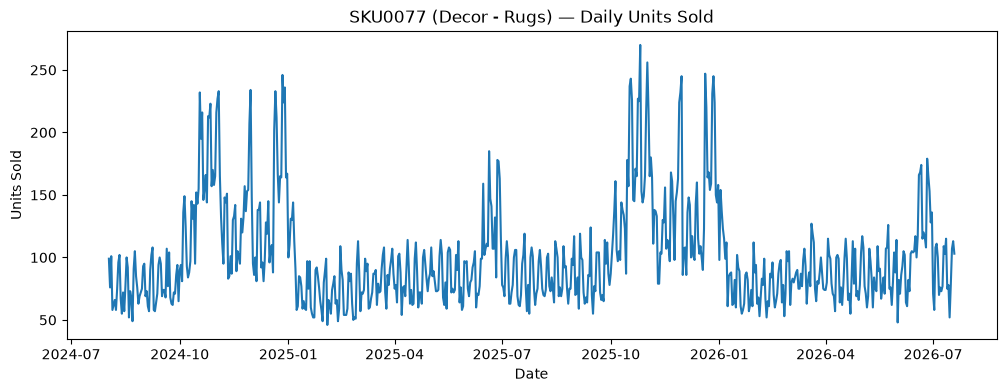

In [5]:
sku0077 = df[df["sku_id"] == "SKU0077"].sort_values("date")

plt.figure(figsize=(12, 4))
plt.plot(sku0077["date"], sku0077["units_sold"])
plt.title("SKU0077 (Decor - Rugs) — Daily Units Sold")
plt.xlabel("Date")
plt.ylabel("Units Sold")
plt.show()

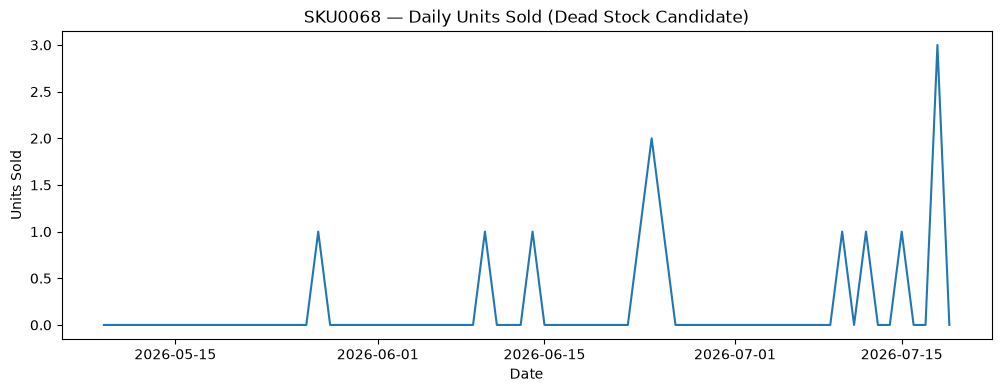

In [6]:
sku0068 = df[df["sku_id"] == "SKU0068"].sort_values("date")

plt.figure(figsize=(12, 4))
plt.plot(sku0068["date"], sku0068["units_sold"])
plt.title("SKU0068 — Daily Units Sold (Dead Stock Candidate)")
plt.xlabel("Date")
plt.ylabel("Units Sold")
plt.show()

In [7]:
sku.loc[sku["sku_id"] == "SKU0068"]

,sku_id,category,subcategory,launch_date,unit_cost,list_price
67,SKU0068,Decor,Candles,2026-05-09,1408.22,2525.33


In [8]:
# how many days has each SKU actually been on sale?
days_active = df.groupby("sku_id")["date"].nunique()

# average daily units sold, per SKU
avg_daily_sales = df.groupby("sku_id")["units_sold"].sum() / days_active

print("Top 10 by average daily sales:")
print(avg_daily_sales.sort_values(ascending=False).head(10))

print("\nBottom 10 by average daily sales (true dead stock candidates):")
print(avg_daily_sales.sort_values(ascending=False).tail(10))

Top 10 by average daily sales:
sku_id
SKU0077    100.881450
SKU0166     58.736842
SKU0195     41.332875
SKU0194     41.132128
SKU0167     35.815642
SKU0126     30.152542
SKU0055     28.362745
SKU0061     27.924581
SKU0140     27.231214
SKU0079     27.207989
dtype: float64

Bottom 10 by average daily sales (true dead stock candidates):
sku_id
SKU0015    0.360335
SKU0071    0.349096
SKU0048    0.295486
SKU0011    0.261261
SKU0026    0.249655
SKU0070    0.212885
SKU0068    0.180556
SKU0163    0.168263
SKU0123    0.134801
SKU0078    0.123967
dtype: float64


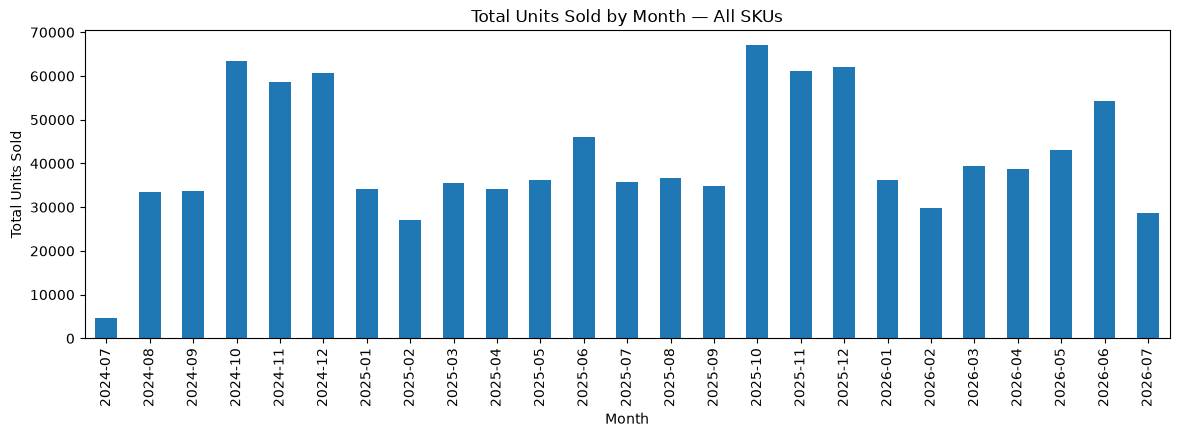

In [9]:
monthly_sales = df.groupby(df["date"].dt.to_period("M"))["units_sold"].sum()

plt.figure(figsize=(14, 4))
monthly_sales.plot(kind="bar")
plt.title("Total Units Sold by Month — All SKUs")
plt.xlabel("Month")
plt.ylabel("Total Units Sold")
plt.xticks(rotation=90)
plt.show()

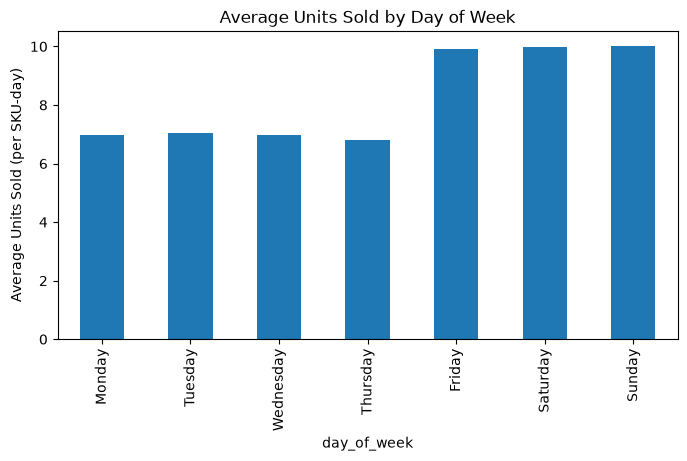

In [10]:
df["day_of_week"] = df["date"].dt.day_name()

dow_sales = df.groupby("day_of_week")["units_sold"].mean()

# reorder so days appear Monday -> Sunday, not alphabetically
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
dow_sales = dow_sales.reindex(day_order)

plt.figure(figsize=(8, 4))
dow_sales.plot(kind="bar")
plt.title("Average Units Sold by Day of Week")
plt.ylabel("Average Units Sold (per SKU-day)")
plt.show()

In [11]:
promo_effect = df.groupby("promo_flag")["units_sold"].mean()
print(promo_effect)

lift_pct = (promo_effect[1] / promo_effect[0] - 1) * 100
print(f"\nPromo lift: {lift_pct:.1f}%")

promo_flag
0     7.162434
1    13.412504
Name: units_sold, dtype: float64

Promo lift: 87.3%


In [12]:
numeric_cols = ["units_sold", "unit_price", "promo_flag", "is_holiday"]
correlation_matrix = df[numeric_cols].corr()
print(correlation_matrix)

            units_sold  unit_price  promo_flag  is_holiday
units_sold    1.000000   -0.033401    0.194029    0.000200
unit_price   -0.033401    1.000000   -0.092981   -0.006141
promo_flag    0.194029   -0.092981    1.000000    0.069674
is_holiday    0.000200   -0.006141    0.069674    1.000000


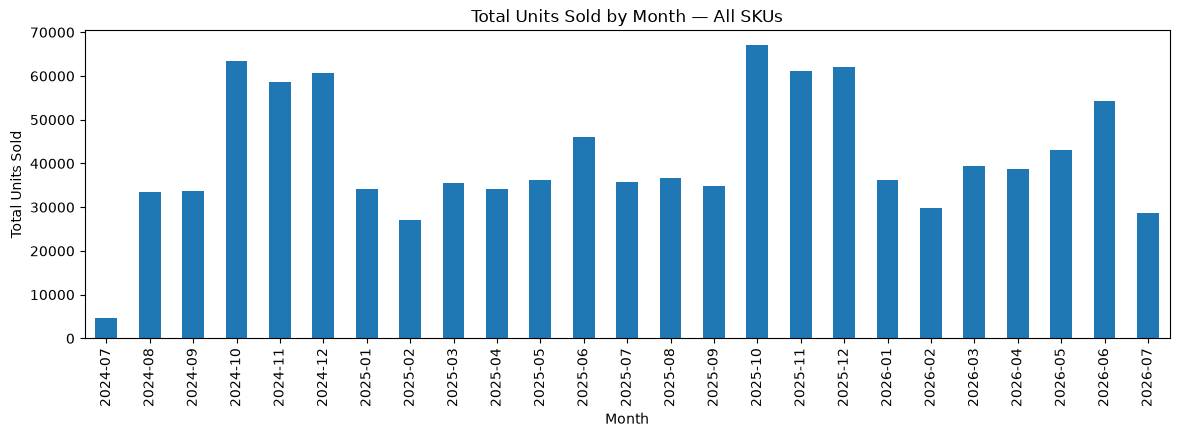

In [13]:
monthly_sales = df.groupby(df["date"].dt.to_period("M"))["units_sold"].sum()

plt.figure(figsize=(14, 4))
monthly_sales.plot(kind="bar")
plt.title("Total Units Sold by Month — All SKUs")
plt.xlabel("Month")
plt.ylabel("Total Units Sold")
plt.xticks(rotation=90)
plt.savefig("../reports/figures/monthly_seasonality.png", bbox_inches="tight")
plt.show()

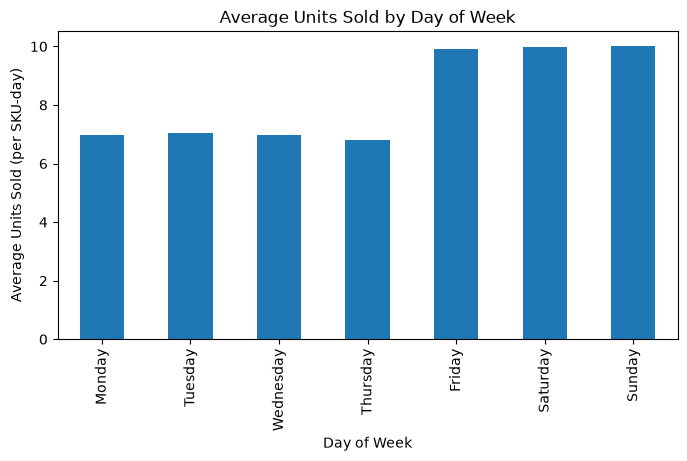

In [14]:
df["day_of_week"] = df["date"].dt.day_name()
dow_sales = df.groupby("day_of_week")["units_sold"].mean()
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
dow_sales = dow_sales.reindex(day_order)

plt.figure(figsize=(8, 4))
dow_sales.plot(kind="bar")
plt.title("Average Units Sold by Day of Week")
plt.ylabel("Average Units Sold (per SKU-day)")
plt.xlabel("Day of Week")
plt.savefig("../reports/figures/day_of_week.png", bbox_inches="tight")
plt.show()

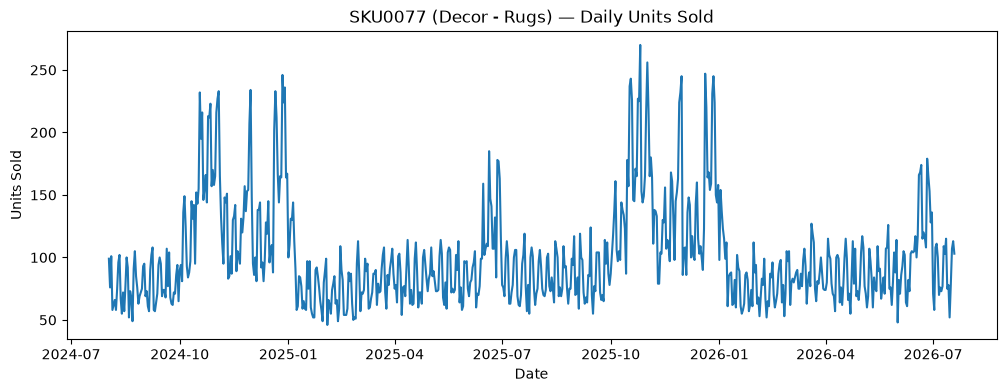

In [15]:
sku0077 = df[df["sku_id"] == "SKU0077"].sort_values("date")

plt.figure(figsize=(12, 4))
plt.plot(sku0077["date"], sku0077["units_sold"])
plt.title("SKU0077 (Decor - Rugs) — Daily Units Sold")
plt.xlabel("Date")
plt.ylabel("Units Sold")
plt.savefig("../reports/figures/sku0077_trend.png", bbox_inches="tight")
plt.show()